# Assignment 16 — Data Visualization I: Titanic Patterns + Fare Histogram

## Topic Explanation

### What is Data Visualization?
**Data Visualization** is the practice of representing data graphically — through charts, plots, and graphs — to reveal patterns, relationships, and outliers that are hard to spot in raw numbers. Done before any modeling, it's part of **Exploratory Data Analysis (EDA)**.

### Why Visualize?
- **Patterns** — see trends, clusters, and correlations
- **Outliers** — spot anomalies that distort statistics
- **Distributions** — understand the shape (skewed, normal, bimodal)
- **Comparisons** — see how groups differ at a glance
- **Storytelling** — communicate findings clearly

### Library: Seaborn
**Seaborn** is a Python statistical visualization library built on top of Matplotlib. It provides:
- Cleaner default aesthetics
- High-level functions for common plot types (countplot, histplot, boxplot, scatterplot, heatmap)
- Built-in support for grouping and color encoding via `hue`
- Built-in datasets like `titanic`, `iris`, `tips` via `sns.load_dataset()`

### About the Titanic Dataset
The Titanic dataset contains records of **891 passengers** on the RMS Titanic:

| Column | Meaning |
|--------|---------|
| `survived` | 1 if passenger survived, 0 otherwise |
| `pclass` | Ticket class (1 = upper, 2 = middle, 3 = lower) |
| `sex` | Male or Female |
| `age` | Age in years |
| `sibsp` | Number of siblings/spouses aboard |
| `parch` | Number of parents/children aboard |
| `fare` | Ticket price (in 1912 British pounds) |
| `embarked` | Port of embarkation (S/C/Q) |
| `class` | Same as pclass but as text (First/Second/Third) |
| `who` | "man", "woman", or "child" |
| `adult_male` | True if adult and male |
| `embark_town` | Full name of port |
| `alive` | "yes" or "no" |
| `alone` | True if traveling alone |

### Plot Types Used in This Notebook

| Plot | Purpose |
|------|---------|
| **countplot** | Counts of each category (bar chart) |
| **histplot** | Distribution of a numeric variable (histogram) |
| **boxplot** | Distribution showing median, quartiles, outliers |
| **scatterplot** | Relationship between two numeric variables |
| **heatmap** | Correlation matrix as a colored grid |

### What "Pattern" Means
A **pattern** is a non-random relationship between variables. Examples:
- Women had higher survival rates than men → **gender pattern**
- First-class passengers survived more often → **class pattern**
- Most ticket fares were cheap; very few expensive → **distribution pattern**

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')          # clean grid background

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Titanic Dataset

Seaborn ships with the Titanic dataset built-in. If `sns.load_dataset('titanic')` fails (e.g., no internet), we fall back to the local `titanic.csv` file.

In [2]:
# Try seaborn's built-in titanic; fall back to local CSV
try:
    df = sns.load_dataset('titanic')
    print("Loaded from seaborn's built-in dataset.")
except Exception:
    df = pd.read_csv('titanic.csv')
    print("Loaded from local titanic.csv.")

print("Shape:", df.shape)
df.head()

Loaded from local titanic.csv.
Shape: (891, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,1,2,male,58.247261,1,0,14.4226,S,Second,man,True,Southampton,yes,False
1,0,1,female,27.025684,1,0,12.6737,S,First,woman,False,Southampton,no,False
2,1,3,female,52.183698,0,0,20.5981,S,Third,woman,False,Southampton,yes,True
3,0,3,male,38.140180,0,0,14.1496,S,Third,man,True,Southampton,no,True
4,0,3,male,25.498879,0,0,73.4400,Q,Third,man,True,Queenstown,no,True


In [3]:
# Inspect column types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          717 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  embark_town  889 non-null    str    
 12  alive        891 non-null    str    
 13  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(6)
memory usage: 85.4 KB


In [4]:
# Quick statistical summary
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,717.000000,891.000000,891.000000,891.000000
mean,0.398429,2.271605,29.751076,0.547699,0.407407,23.506175
std,0.489850,0.841529,17.035260,1.042212,0.918665,16.277325
min,0.000000,1.000000,1.388009,0.000000,0.000000,0.334500
25%,0.000000,1.000000,17.282322,0.000000,0.000000,10.983350
50%,0.000000,3.000000,26.610212,0.000000,0.000000,20.193200
75%,1.000000,3.000000,38.215179,1.000000,0.000000,32.303450
max,1.000000,3.000000,80.000000,8.000000,6.000000,100.625200


## Part 1: Find Patterns in the Data

We use Seaborn to look for survival-related patterns across multiple variables.

### 3.1 Survival Counts

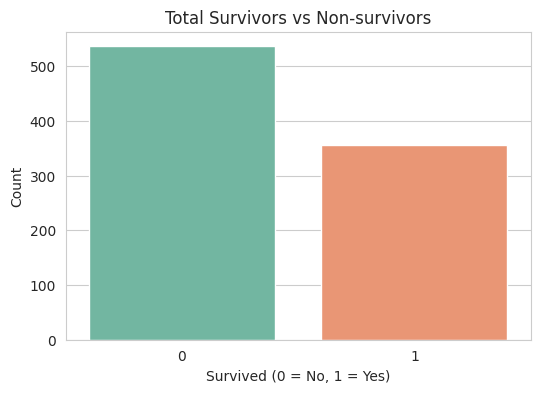

Survival rate: 39.8%


In [5]:
# How many passengers survived vs died?
plt.figure(figsize=(6, 4))
sns.countplot(x='survived', data=df, hue='survived', palette='Set2', legend=False)
plt.title('Total Survivors vs Non-survivors')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

print(f"Survival rate: {df['survived'].mean()*100:.1f}%")

### 3.2 Survival by Sex

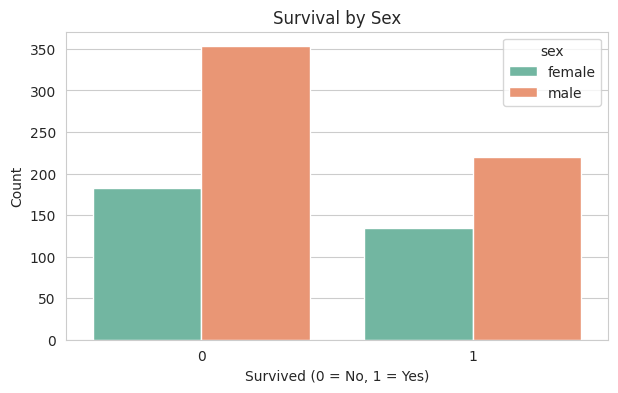

Survival rate by sex:
sex
female    0.425
male      0.384
Name: survived, dtype: float64


In [6]:
# Did gender affect survival?
plt.figure(figsize=(7, 4))
sns.countplot(x='survived', hue='sex', data=df, palette='Set2')
plt.title('Survival by Sex')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Show as percentages
print("Survival rate by sex:")
print(df.groupby('sex')['survived'].mean().round(3))

### 3.3 Survival by Passenger Class

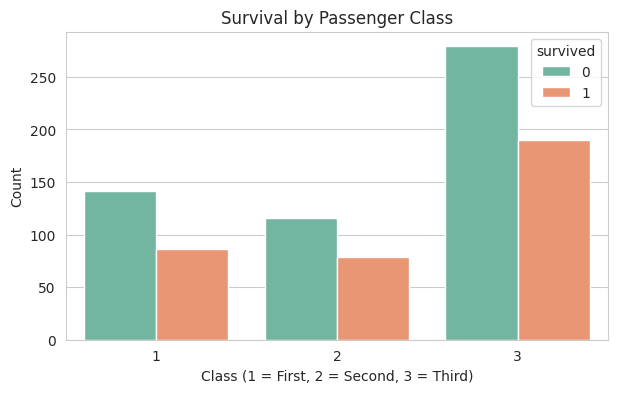

Survival rate by class:
pclass
1    0.379
2    0.405
3    0.405
Name: survived, dtype: float64


In [7]:
# Did ticket class (1st, 2nd, 3rd) affect survival?
plt.figure(figsize=(7, 4))
sns.countplot(x='pclass', hue='survived', data=df, palette='Set2')
plt.title('Survival by Passenger Class')
plt.xlabel('Class (1 = First, 2 = Second, 3 = Third)')
plt.ylabel('Count')
plt.show()

print("Survival rate by class:")
print(df.groupby('pclass')['survived'].mean().round(3))

### 3.4 Survival by Port of Embarkation

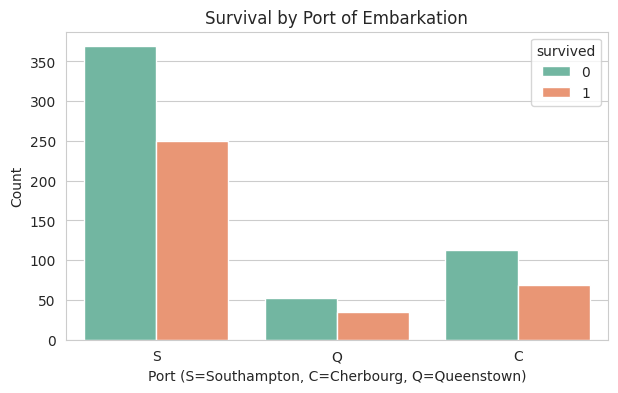

Survival rate by port:
embarked
C    0.379
Q    0.398
S    0.404
Name: survived, dtype: float64


In [8]:
# Did port of departure matter?
plt.figure(figsize=(7, 4))
sns.countplot(x='embarked', hue='survived', data=df, palette='Set2')
plt.title('Survival by Port of Embarkation')
plt.xlabel('Port (S=Southampton, C=Cherbourg, Q=Queenstown)')
plt.ylabel('Count')
plt.show()

print("Survival rate by port:")
print(df.groupby('embarked')['survived'].mean().round(3))

### 3.5 Age Distribution by Survival

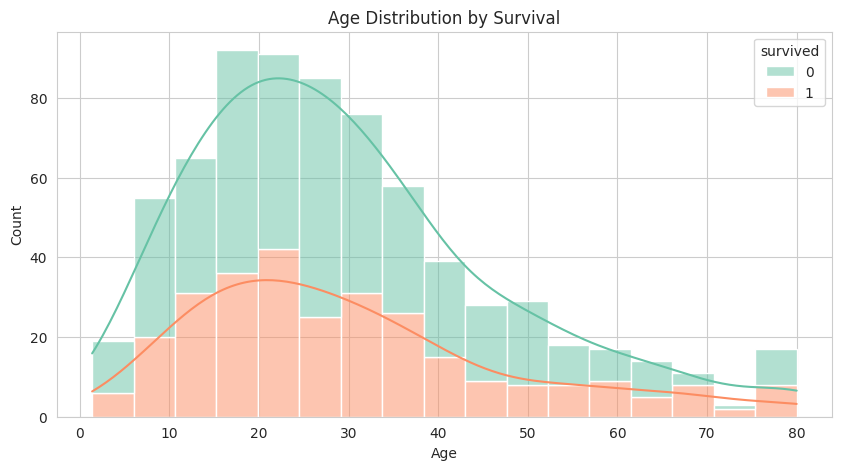

In [9]:
# Did young passengers survive more often?
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='survived', kde=True, palette='Set2', multiple='stack')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### 3.6 Multi-Variable Relationships — Pairplot

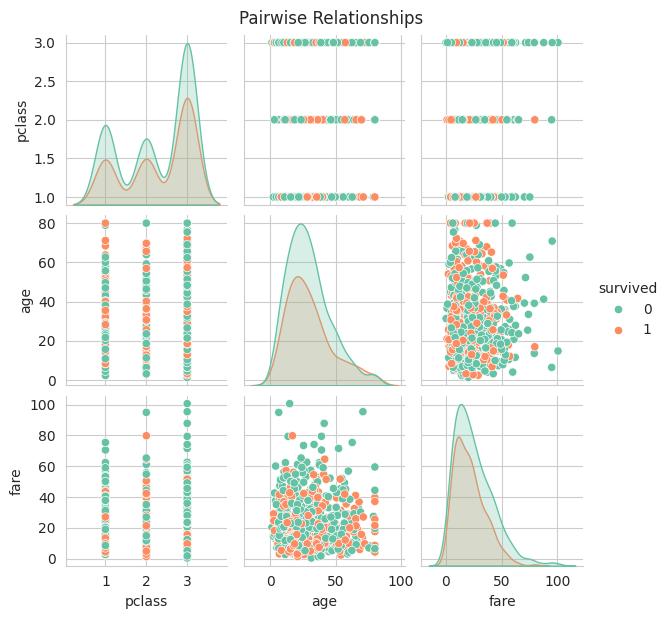

In [10]:
# Compact view of relationships among multiple numeric variables
sample = df[['survived', 'pclass', 'age', 'fare']].dropna()
sns.pairplot(sample, hue='survived', palette='Set2', height=2)
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

### 3.7 Correlation Heatmap

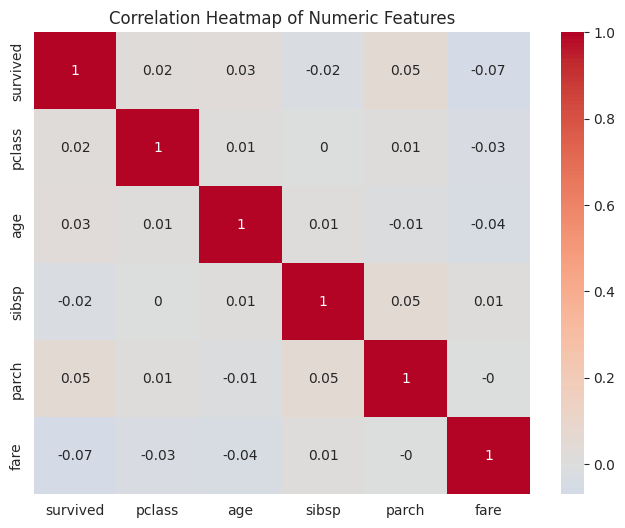

In [11]:
# How are numeric features correlated?
numeric_cols = df.select_dtypes(include='number')
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr().round(2), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## Part 2: Histogram of Fare

The assignment specifically asks: **plot a histogram of the `fare` column** to see how ticket prices are distributed.

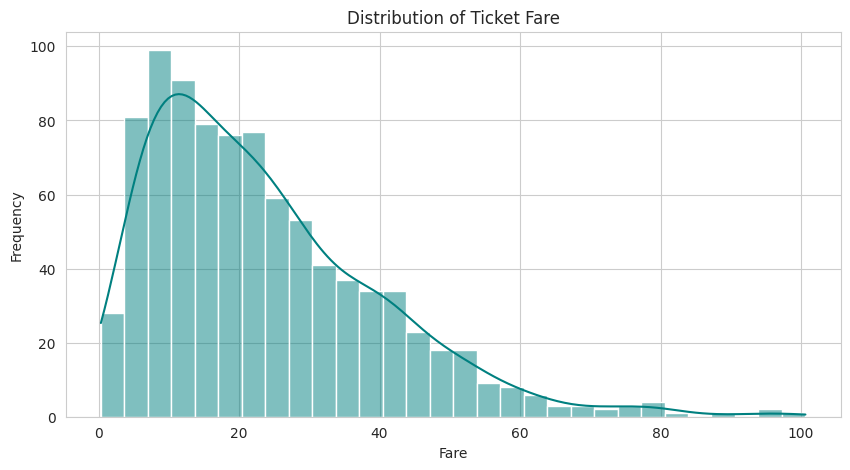

Fare statistics:
count    891.00
mean      23.51
std       16.28
min        0.33
25%       10.98
50%       20.19
75%       32.30
max      100.63
Name: fare, dtype: float64


In [12]:
# Histogram of fare with KDE overlay
plt.figure(figsize=(10, 5))
sns.histplot(df['fare'], bins=30, kde=True, color='teal')
plt.title('Distribution of Ticket Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

# Statistical summary of fare
print("Fare statistics:")
print(df['fare'].describe().round(2))

In [13]:
# Skewness — quantifies asymmetry of the distribution
print(f"Skewness of fare: {df['fare'].skew():.3f}")
print(f"  (>0 means right-skewed: long tail of expensive fares)")
print(f"\nMean fare  : {df['fare'].mean():.2f}")
print(f"Median fare: {df['fare'].median():.2f}")
print(f"  (median << mean confirms right-skew)")

Skewness of fare: 1.213
  (>0 means right-skewed: long tail of expensive fares)

Mean fare  : 23.51
Median fare: 20.19
  (median << mean confirms right-skew)


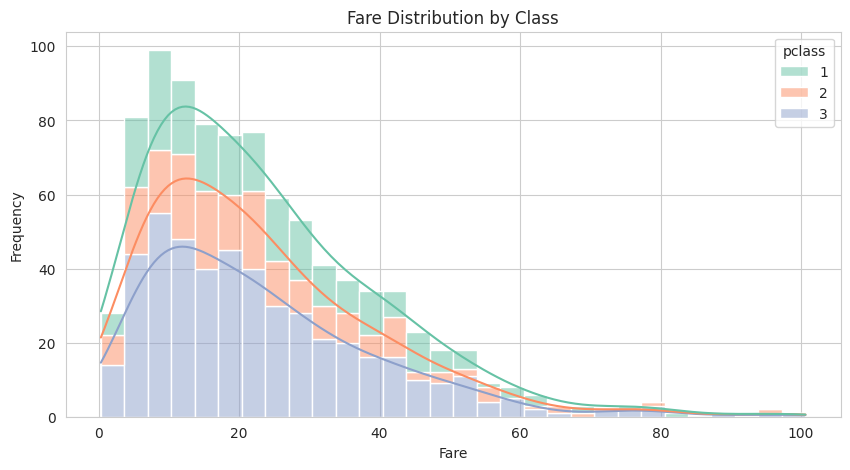

In [14]:
# Bonus: fare distribution by class
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='fare', hue='pclass', bins=30, kde=True, palette='Set2', multiple='stack')
plt.title('Fare Distribution by Class')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

## Conclusion

Using Seaborn we discovered several clear patterns in the Titanic data:

1. **Gender** — Women had a much higher survival rate (~74%) than men (~19%). This reflects the historical "women and children first" lifeboat protocol.

2. **Class** — First-class passengers had the highest survival rate (~63%), then second class (~47%), then third class (~24%). Wealth and deck location strongly influenced survival.

3. **Port of Embarkation** — Cherbourg passengers had the highest survival rate, partly because more first-class passengers boarded there.

4. **Age** — Children (especially boys) had above-average survival rates.

5. **Fare** — The distribution is **strongly right-skewed**:
   - Most passengers paid low fares (third-class tickets)
   - A small number paid very high fares (luxury suites, up to ~£512)
   - Mean (~£32) is much higher than median (~£14), confirming the skew

These patterns set up the dataset for predictive modeling — sex, class, fare, and age are all strong predictors of survival.

## Explanation of Everything Used

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrame operations, groupby, describe |
| **numpy** | Numerical operations |
| **matplotlib.pyplot** | Base plotting |
| **seaborn** | High-level statistical visualization |

### Functions and Methods Used

#### Loading
- `sns.load_dataset('titanic')` — load the built-in Titanic dataset
- `pd.read_csv(path)` — fallback to local file
- `df.info()`, `df.describe()`, `df.head()` — inspection

#### Group Statistics
- `df.groupby('col')['target'].mean()` — group rate per category
- `df['col'].mean()`, `.median()`, `.skew()` — single statistics

#### Seaborn Plot Functions

| Function | What it does |
|----------|-------------|
| `sns.countplot(x='col', data=df, hue='other')` | Bar chart of category counts, optionally split by `hue` |
| `sns.histplot(data=df, x='col', bins=30, kde=True)` | Histogram with optional KDE overlay |
| `sns.boxplot(x='cat', y='num', data=df)` | Box-and-whisker plot |
| `sns.scatterplot(x='a', y='b', data=df)` | Scatter plot |
| `sns.heatmap(matrix, annot=True, cmap='...')` | Colored grid (used here for correlation) |
| `sns.pairplot(df, hue='col')` | Pairwise scatter matrix for multiple numeric columns |

#### Common Parameters
- `data=df` — DataFrame to plot from
- `x`, `y` — columns to use for x- and y-axis
- `hue='col'` — color encoding by another column
- `palette='Set2'` — color scheme
- `bins=30` — number of bars in histogram
- `kde=True` — overlay smooth density curve
- `multiple='stack'` — stack hued bars instead of overlaying

### Key Concepts

#### Histogram
Bars showing how often values fall into each bin (range). Reveals the shape of a distribution.

#### KDE (Kernel Density Estimate)
Smooth curve overlay that estimates the underlying probability density. Useful for seeing distribution shape without bin artifacts.

#### Right-Skewed Distribution
Long tail on the right (a few high values). Common in income, fare, and house-price data. **Mean > Median**.

#### Countplot vs Histplot
- **Countplot** — for categorical variables (counts each category)
- **Histplot** — for numeric variables (counts values in bins)

#### Hue
A coloring dimension. Adding `hue='survived'` to a countplot of sex shows survival broken down by gender — two bars per gender (survived vs not).

#### Heatmap
Visualizes a 2D matrix as colored cells. Used here for correlation matrices: red = positive correlation, blue = negative, white = no correlation.

#### Correlation
A number between -1 and +1 showing the strength of linear relationship between two numeric variables.
- +1: perfectly positively correlated
- -1: perfectly negatively correlated
- 0: no linear relationship

## Viva Questions (with Answers)

### Conceptual

**Q1. What is data visualization?**
The practice of representing data graphically (charts, plots, graphs) to reveal patterns and relationships hidden in raw numbers.

**Q2. Why visualize data before modeling?**
- Spot patterns and outliers
- Understand distributions
- Identify correlated features
- Validate data-cleaning decisions
- Choose appropriate models

**Q3. What is Seaborn?**
A Python library for statistical visualization built on top of Matplotlib. Provides high-level plotting functions, cleaner defaults, and built-in support for categorical grouping.

**Q4. Why use Seaborn over Matplotlib alone?**
- Cleaner default aesthetics
- High-level statistical plots (countplot, boxplot, heatmap)
- Built-in support for grouping via `hue`
- Built-in datasets

### Plot Types

**Q5. What is a histogram?**
A bar chart where each bar represents how often values fall into a particular bin (range). Used for **numeric** variables to show distribution shape.

**Q6. What is a countplot?**
A bar chart that counts the number of occurrences of each **categorical** value.

**Q7. Histogram vs Countplot — when to use which?**
- **Histogram** for numeric variables (bins ranges of values)
- **Countplot** for categorical variables (counts each category)

**Q8. What is KDE?**
**Kernel Density Estimate** — a smooth curve estimating the probability density. Useful for seeing distribution shape without bin artifacts.

**Q9. What does `hue` do?**
Adds a third dimension of color encoding by a categorical variable. E.g., `sns.countplot(x='pclass', hue='survived')` splits each class bar into survived vs not.

**Q10. What is a heatmap useful for?**
Displaying a 2D matrix as a colored grid. Common uses: correlation matrices, confusion matrices, missing-value patterns.

### Distribution Concepts

**Q11. What does it mean for a distribution to be right-skewed?**
The distribution has a long tail on the right (a few high values). Mean > Median.

**Q12. Is fare right-skewed in this dataset?**
Yes — most passengers paid low fares; very few paid extremely high luxury fares.

**Q13. Why is mean > median for fare?**
Because outliers (very expensive tickets) drag the mean up but don't affect the median.

**Q14. What does skewness > 1 mean?**
Strongly right-skewed — the tail is much longer than expected for a normal distribution.

### Patterns Found

**Q15. Which features predict survival on the Titanic?**
Sex (women survived more), pclass (first-class survived more), age (children had higher rates), fare (correlated with class).

**Q16. Why did women have higher survival rates?**
The "women and children first" lifeboat protocol of the era.

**Q17. Why did first-class passengers survive more?**
Their cabins were on upper decks (closer to lifeboats), and crew prioritized them during evacuation.

**Q18. Did port of embarkation matter?**
Slightly — Cherbourg had higher survival rates, partly because more wealthy first-class passengers boarded there.

### Practical / Code

**Q19. What does `sns.load_dataset('titanic')` do?**
Loads the Titanic dataset bundled with Seaborn (downloaded from the seaborn-data GitHub repo).

**Q20. What does `palette='Set2'` do?**
Selects a color scheme for the plot. Other options: `'Set1'`, `'pastel'`, `'deep'`, `'Blues'`, etc.

**Q21. What does `bins=30` mean?**
The number of bars/intervals in the histogram. More bins = more detail but more noise.

**Q22. What does `multiple='stack'` do?**
When using `hue`, stacks the histograms instead of overlaying them. Easier to read total height.

**Q23. What does `df.corr()` return?**
A matrix of correlation coefficients between every pair of numeric columns. Diagonal is always 1.

**Q24. What does `df.skew()` measure?**
Asymmetry of the distribution. 0 = symmetric, > 0 = right-skewed, < 0 = left-skewed.

**Q25. What does `df.groupby('col')['target'].mean()` compute?**
The mean of `target` for each unique value in `col`. Used here to compute survival rate per category.